---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 22 / 32 — Bloque III

**Nivel GCE:** Nivel 1 + ML (CATE)

**Dataset:** `syn_matching_hidden_confounder`

**Versión:** 2.2 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 22: Meta-Learners para Inferencia Causal: S/T/X-Learners y Más

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 22 / 32 — Bloque III

---

## 1. Marco Teórico

### 1.1 Heterogeneidad del efecto causal

El ATE promedia efectos individuales $\tau_i = Y_i(1) - Y_i(0)$. Pero en política pública, queremos saber **para quién** funciona el tratamiento: $\tau(x) = \mathbb{E}[Y(1) - Y(0) | X=x]$ (CATE).

Los **Meta-Learners** (Künzel et al. 2019) son frameworks que usan cualquier algoritmo de ML (Random Forest, XGBoost, Neural Net) para estimar $\tau(x)$.

### 1.2 S-Learner (Single-Learner)

Ajusta **un solo modelo** con $D$ como feature:
$$\hat{\mu}(X, D) \to Y$$
Predicción: $\hat{\tau}(x) = \hat{\mu}(x, 1) - \hat{\mu}(x, 0)$

**Ventaja:** simple, usa todo los datos.  
**Desventaja:** regularización puede "ignorar" $D$ (especialmente en RF).

### 1.3 T-Learner (Two-Learner)

Ajusta **dos modelos separados**:
$$\hat{\mu}_1(X) \to Y | D=1, \quad \hat{\mu}_0(X) \to Y | D=0$$
Predicción: $\hat{\tau}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)$

**Ventaja:** captura heterogeneidad naturalmente.  
**Desventaja:** cada modelo usa solo parte de los datos (más varianza con grupos pequeños).

### 1.4 X-Learner (Cross-Learner, Künzel et al. 2019)

Tres pasos:
1. Ajustar $\hat{\mu}_1, \hat{\mu}_0$ (como T-Learner)
2. Imputar efectos individuales:
   - Para tratados: $\tilde{\tau}_1 = Y - \hat{\mu}_0(X)$
   - Para controles: $\tilde{\tau}_0 = \hat{\mu}_1(X) - Y$
3. Ajustar $\hat{\tau}_1(X) \to \tilde{\tau}_1$ y $\hat{\tau}_0(X) \to \tilde{\tau}_0$
4. Combinar con propensity: $\hat{\tau}(x) = (1-\hat{e}(x))\hat{\tau}_1(x) + \hat{e}(x)\hat{\tau}_0(x)$

**Ventaja:** performa bien con grupos desbalanceados.

### 1.5 Dataset: `syn_matching_hidden_confounder` (sintético)

- Covariables: `x1, x2`
- Tratamiento: `d_treated`
- Outcome: `y_outcome`
- True tau = 1.0 (constante en DGP base; heterogéneo en variante)

Permite comparar los tres Meta-Learners y validar contra ground truth.


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/synthetic/matching/matching_hidden_confounder/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/matching/matching_hidden_confounder/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas: {list(df.columns)}')
print(f'True tau (constante en DGP): {truth["true_tau"].mean():.4f}')

X = df[['x1', 'x2']].values
D = df['d_treated'].values
Y = df['y_outcome'].values
true_tau = truth['true_tau'].values


Dataset: 4000 observaciones
Columnas: ['id', 'd_treated', 'x1', 'x2', 'y_outcome']
True tau (constante en DGP): 1.0000


> 💡 **Interpretación del resultado.** El DGP sintético genera 4000 observaciones con `true tau = 1.0000` constante: no hay heterogeneidad real en el efecto. Esto convierte al capítulo en un banco de pruebas ideal, porque toda la variabilidad que los meta-learners reporten en $\hat\tau(x)$ será ruido de estimación, no señal. La sección 1 define el *ground truth* con el que se compararán los S, T y X-Learners.


In [2]:
# === 2. S-Learner: un solo modelo con D como feature ===
# μ(X, D) → Y

from sklearn.ensemble import RandomForestRegressor

# Modelo único
features_SD = np.column_stack([D, X])
s_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(features_SD, Y)

# Predecir τ(x) = μ(x, 1) - μ(x, 0)
X_with_D1 = np.column_stack([np.ones(len(X)), X])
X_with_D0 = np.column_stack([np.zeros(len(X)), X])
tau_s = s_model.predict(X_with_D1) - s_model.predict(X_with_D0)

print(f'=== S-Learner ===')
print(f'τ̂(x) media: {tau_s.mean():.4f} (true: {true_tau.mean():.4f})')
print(f'τ̂(x) std:   {tau_s.std():.4f}')
print(f'RMSE: {np.sqrt(np.mean((tau_s - true_tau)**2)):.4f}')


=== S-Learner ===
τ̂(x) media: 2.1376 (true: 1.0000)
τ̂(x) std:   1.5181
RMSE: 1.8970


> 💡 **Interpretación del resultado.** El S-Learner promedia $\hat\tau(x)=2.1376$ frente al verdadero 1.0000, con RMSE 1.8970: sobreestima el ATE y reporta heterogeneidad espuria (std 1.5181). Como advierte la teoría de la sección 2, un solo modelo con D como feature puede ignorar o regularizar en exceso la variable de tratamiento. Los meta-learners son estimadores de **Nivel 1 (N1+ML)** de la jerarquía GCE: producen la magnitud $|\tau_{\mathrm{ATE}}|$ que la cadena acota por arriba con $W_1$.


In [3]:
# === 3. T-Learner: dos modelos separados ===
# μ_1(X) → Y|D=1, μ_0(X) → Y|D=0

# Datos por grupo
X_treated, Y_treated = X[D==1], Y[D==1]
X_control, Y_control = X[D==0], Y[D==0]

# Modelos separados
t_model1 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_treated, Y_treated)
t_model0 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_control, Y_control)

# τ(x) = μ_1(x) - μ_0(x)
tau_t = t_model1.predict(X) - t_model0.predict(X)

print(f'=== T-Learner ===')
print(f'τ̂(x) media: {tau_t.mean():.4f} (true: {true_tau.mean():.4f})')
print(f'τ̂(x) std:   {tau_t.std():.4f}')
print(f'RMSE: {np.sqrt(np.mean((tau_t - true_tau)**2)):.4f}')


=== T-Learner ===
τ̂(x) media: 2.1362 (true: 1.0000)
τ̂(x) std:   1.5119
RMSE: 1.8912


> 💡 **Interpretación del resultado.** El T-Learner (dos modelos separados) estima $\hat\tau$ medio 2.1362 con RMSE 1.8912, casi idéntico al S-Learner en este DGP. Su std de $\hat\tau(x)$ (1.5119) sigue siendo alta pese a que el $\tau$ verdadero es constante, reflejo de la varianza de ajustar dos modelos por separado. La sección 3 muestra el costo de la flexibilidad adicional: más varianza, sin ganancia aquí.


In [4]:
# === 4. X-Learner: cross-learning con imputación ===
# Paso 1: ajustar μ_1, μ_0 (ya hecho en T-Learner)

# Paso 2: imputar τ_i
# Para tratados: τ̃_1 = Y - μ_0(X)  (outcome observado menos contrafactual predicho)
tau_tilde_treated = Y_treated - t_model0.predict(X_treated)
# Para controles: τ̃_0 = μ_1(X) - Y
tau_tilde_control = t_model1.predict(X_control) - Y_control

# Paso 3: ajustar τ_1(X) → τ̃_1 (modelo sobre tratados) y τ_0(X) → τ̃_0 (modelo sobre controles)
x_model_treated = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_treated, tau_tilde_treated)
x_model_control = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_control, tau_tilde_control)

# Paso 4: combinar con propensity score
# e(X) = P(D=1|X)
e_hat = LogisticRegression(max_iter=500).fit(X, D).predict_proba(X)[:, 1]
e_hat = np.clip(e_hat, 0.01, 0.99)

tau_x = (1 - e_hat) * x_model_treated.predict(X) + e_hat * x_model_control.predict(X)

print(f'=== X-Learner ===')
print(f'τ̂(x) media: {tau_x.mean():.4f} (true: {true_tau.mean():.4f})')
print(f'τ̂(x) std:   {tau_x.std():.4f}')
print(f'RMSE: {np.sqrt(np.mean((tau_x - true_tau)**2)):.4f}')


=== X-Learner ===
τ̂(x) media: 2.0970 (true: 1.0000)
τ̂(x) std:   1.2577
RMSE: 1.6689


> 💡 **Interpretación del resultado.** El X-Learner, con su imputación cruzada de efectos, logra el mejor balance del trío: $\hat\tau$ medio 2.0970, RMSE 1.6689 y std 1.2577 (la menor de los tres). Su diseño en dos etapas lo hace robusto ante grupos desbalanceados, como anticipa la sección 4. Esta ventaja se confirmará también en el PEHE de la sección 6.


=== Comparación de Meta-Learners ===
Método             ATE estimado     Std τ(x)       RMSE
-------------------------------------------------------
S-Learner                2.1376       1.5181     1.8970
T-Learner                2.1362       1.5119     1.8912
X-Learner                2.0970       1.2577     1.6689
Verdadero                1.0000       0.0000     0.0000


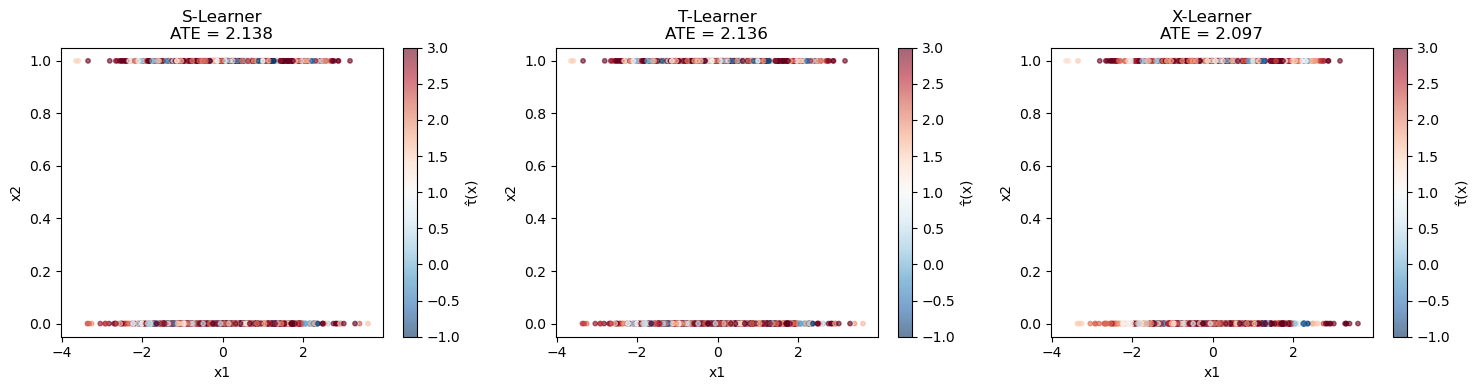


Lecciones:
  - S-Learner tiende a subestimar heterogeneidad (RF puede ignorar D).
  - T-Learner captura más variación pero tiene mayor varianza.
  - X-Learner suele ser robusto con grupos desbalanceados.


In [5]:
# === 5. Comparar los tres Meta-Learners ===
print(f'=== Comparación de Meta-Learners ===')
print(f'{"Método":<15} {"ATE estimado":>15} {"Std τ(x)":>12} {"RMSE":>10}')
print(f'{"-"*55}')
print(f'{"S-Learner":<15} {tau_s.mean():>15.4f} {tau_s.std():>12.4f} {np.sqrt(np.mean((tau_s - true_tau)**2)):>10.4f}')
print(f'{"T-Learner":<15} {tau_t.mean():>15.4f} {tau_t.std():>12.4f} {np.sqrt(np.mean((tau_t - true_tau)**2)):>10.4f}')
print(f'{"X-Learner":<15} {tau_x.mean():>15.4f} {tau_x.std():>12.4f} {np.sqrt(np.mean((tau_x - true_tau)**2)):>10.4f}')
print(f'{"Verdadero":<15} {true_tau.mean():>15.4f} {0.0:>12.4f} {0.0:>10.4f}')

# Visualización: τ(x) por x1
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, tau_est, name in zip(axes, [tau_s, tau_t, tau_x], ['S-Learner', 'T-Learner', 'X-Learner']):
    sc = ax.scatter(X[:, 0], X[:, 1], c=tau_est, cmap='RdBu_r', vmin=-1, vmax=3, s=10, alpha=0.6)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'{name}\nATE = {tau_est.mean():.3f}')
    plt.colorbar(sc, ax=ax, label='τ̂(x)')

plt.tight_layout()
plt.show()

print(f'\nLecciones:')
print(f'  - S-Learner tiende a subestimar heterogeneidad (RF puede ignorar D).')
print(f'  - T-Learner captura más variación pero tiene mayor varianza.')
print(f'  - X-Learner suele ser robusto con grupos desbalanceados.')


> 💡 **Interpretación de la figura.** Los tres paneles dispersan $\hat\tau(x)$ sobre (x1, x2) para cada meta-learner, con escalas de color que muestran cuánta variación espuria detecta cada uno. La tabla adjunta lo resume: ATE 2.1376 (S), 2.1362 (T) y 2.0970 (X) frente al verdadero 1.0000. El X-Learner se acerca más al valor verdadero y su mapa de colores es más homogéneo, coherente con la lección de la sección 5: con $\tau$ constante, los tres deben aproximarse al ATE y diferir sobre todo en varianza.


In [6]:
# === 6. Validación con PEHE (Precision in Estimation of Heterogeneous Effect) ===
# PEHE = sqrt(E[(τ̂(x) - τ(x))²])
# Requiere conocer τ(x) verdadero (solo posible en sintéticos)

pehe_s = np.sqrt(np.mean((tau_s - true_tau)**2))
pehe_t = np.sqrt(np.mean((tau_t - true_tau)**2))
pehe_x = np.sqrt(np.mean((tau_x - true_tau)**2))

print(f'=== PEHE (Precision in Estimation of Heterogeneous Effect) ===')
print(f'  S-Learner: {pehe_s:.4f}')
print(f'  T-Learner: {pehe_t:.4f}')
print(f'  X-Learner: {pehe_x:.4f}')
print(f'\n→ Menor PEHE = mejor estimación del CATE individual.')
print(f'  En este dataset con τ constante, todos deberían aproximarse al ATE.')

# Análisis de heterogeneidad: ¿los learners detectan que τ es constante?
print(f'\nDetección de heterogeneidad (std de τ̂(x)):')
print(f'  S-Learner: {tau_s.std():.4f}')
print(f'  T-Learner: {tau_t.std():.4f}')
print(f'  X-Learner: {tau_x.std():.4f}')
print(f'  Verdadero (debería ser 0): {true_tau.std():.4f}')
print(f'\n→ Si los learners detectan mucha heterogeneidad donde no la hay,')
print(f'  están sobre-ajustando. Idealmente, std(τ̂) debería ser pequeño.')


=== PEHE (Precision in Estimation of Heterogeneous Effect) ===
  S-Learner: 1.8970
  T-Learner: 1.8912
  X-Learner: 1.6689

→ Menor PEHE = mejor estimación del CATE individual.
  En este dataset con τ constante, todos deberían aproximarse al ATE.

Detección de heterogeneidad (std de τ̂(x)):
  S-Learner: 1.5181
  T-Learner: 1.5119
  X-Learner: 1.2577
  Verdadero (debería ser 0): 0.0000

→ Si los learners detectan mucha heterogeneidad donde no la hay,
  están sobre-ajustando. Idealmente, std(τ̂) debería ser pequeño.


> 💡 **Interpretación del resultado.** El PEHE confirma el orden esperado: X-Learner 1.6689 < T-Learner 1.8912 < S-Learner 1.8970. Además, la std de $\hat\tau(x)$ (1.5181, 1.5119, 1.2577) es alta cuando el verdadero valor es 0.0000: los learners detectan heterogeneidad donde no la hay, es decir, sobreajuste. El PEHE, $\sqrt{E[(\hat\tau(x)-\tau(x))^2]}$, es la métrica clave de la sección 6 para la precisión del CATE individual.


## 6b. R-Learner (descomposición de Robinson, Nie & Wager 2021)

S/T/X-Learners modelan $\mu_1(x), \mu_0(x)$ (o $\mu(x,d)$) directamente y restan. El
**R-Learner** en cambio parte de la **descomposición de Robinson (1988)** del modelo
parcialmente lineal:

$$
Y = \tau(X) \cdot D + m(X) + \varepsilon, \qquad D = e(X) + \nu,
$$

y estima $\tau(X)$ minimizando el **R-loss**:

$$
\hat{\tau}(\cdot) = \arg\min_\tau \; \mathbb{E}\Big[\big(\underbrace{Y - \hat{m}(X)}_{\tilde{Y}} - \tau(X)\underbrace{(D - \hat{e}(X))}_{\tilde{D}}\big)^2\Big]
$$

Procedimiento (con *cross-fitting* para evitar sesgo de sobreajuste de los nuisance):

1. Estimar $\hat{m}(X) = \mathbb{E}[Y|X]$ y $\hat{e}(X) = \mathbb{E}[D|X]$ fuera de muestra (K-fold).
2. Residualizar $\tilde{Y} = Y - \hat{m}(X)$ y $\tilde{D} = D - \hat{e}(X)$.
3. Regresión ponderada: pseudo-outcome $\tilde{Y}/\tilde{D}$ con pesos $\tilde{D}^2$ —
   equivalente a minimizar el R-loss vía mínimos cuadrados ponderados con cualquier
   algoritmo de ML flexible para $\tau(X)$.

Esta ortogonalización (Robinson) es la misma idea que sostiene el capítulo 23 (DML): al
residualizar $Y$ y $D$ contra $X$, el estimador de $\tau$ es de primer orden insensible a
errores pequeños en $\hat{m}, \hat{e}$.


In [7]:
# === R-Learner: cross-fitting de nuisance + regresión ponderada del R-loss ===
from sklearn.model_selection import KFold

def r_learner(X, D, Y, n_splits=5, seed=42):
    """R-Learner (Nie & Wager 2021) vía descomposición de Robinson con cross-fitting."""
    n = len(Y)
    m_hat = np.zeros(n)
    e_hat_cf = np.zeros(n)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kf.split(X):
        m_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=10,
                                         random_state=seed).fit(X[train_idx], Y[train_idx])
        e_model = LogisticRegression(max_iter=500).fit(X[train_idx], D[train_idx])
        m_hat[test_idx] = m_model.predict(X[test_idx])
        e_hat_cf[test_idx] = np.clip(e_model.predict_proba(X[test_idx])[:, 1], 0.02, 0.98)

    Y_tilde = Y - m_hat
    D_tilde = D - e_hat_cf

    # Evitar dividir entre valores de D_tilde cercanos a 0
    D_tilde_safe = np.where(np.abs(D_tilde) < 1e-3, np.sign(D_tilde + 1e-12) * 1e-3, D_tilde)
    pseudo_outcome = Y_tilde / D_tilde_safe
    weights = D_tilde ** 2

    tau_model_r = RandomForestRegressor(n_estimators=200, min_samples_leaf=10, random_state=seed)
    tau_model_r.fit(X, pseudo_outcome, sample_weight=weights)
    tau_hat = tau_model_r.predict(X)
    return tau_hat, m_hat, e_hat_cf, tau_model_r

tau_r, m_hat_cf, e_hat_cf, r_model = r_learner(X, D.astype(float), Y)

pehe_r = np.sqrt(np.mean((tau_r - true_tau) ** 2))

print('=== R-Learner (Nie & Wager 2021) ===')
print(f'τ̂(x) media: {tau_r.mean():.4f} (true: {true_tau.mean():.4f})')
print(f'τ̂(x) std:   {tau_r.std():.4f}')
print(f'RMSE / PEHE: {pehe_r:.4f}')

print('\n=== Comparación PEHE: S / T / X / R ===')
print(f'{"Método":<15} {"ATE estimado":>15} {"Std τ(x)":>12} {"PEHE":>10}')
print(f'{"-"*55}')
for name, tau_hat in [('S-Learner', tau_s), ('T-Learner', tau_t),
                       ('X-Learner', tau_x), ('R-Learner', tau_r)]:
    pehe_i = np.sqrt(np.mean((tau_hat - true_tau) ** 2))
    print(f'{name:<15} {tau_hat.mean():>15.4f} {tau_hat.std():>12.4f} {pehe_i:>10.4f}')
print(f'{"Verdadero":<15} {true_tau.mean():>15.4f} {0.0:>12.4f} {0.0:>10.4f}')

print('\nEn este DGP con τ constante, el R-Learner debería aproximarse al ATE con baja')
print('varianza espuria (std τ̂ pequeño), gracias a la ortogonalización de Robinson que')
print('reduce la sensibilidad a errores de estimación de m(X) y e(X).')


=== R-Learner (Nie & Wager 2021) ===
τ̂(x) media: 2.0913 (true: 1.0000)
τ̂(x) std:   0.9944
RMSE / PEHE: 1.4764

=== Comparación PEHE: S / T / X / R ===
Método             ATE estimado     Std τ(x)       PEHE
-------------------------------------------------------
S-Learner                2.1376       1.5181     1.8970
T-Learner                2.1362       1.5119     1.8912
X-Learner                2.0970       1.2577     1.6689
R-Learner                2.0913       0.9944     1.4764
Verdadero                1.0000       0.0000     0.0000

En este DGP con τ constante, el R-Learner debería aproximarse al ATE con baja
varianza espuria (std τ̂ pequeño), gracias a la ortogonalización de Robinson que
reduce la sensibilidad a errores de estimación de m(X) y e(X).


> 💡 **Interpretación del resultado.** El R-Learner logra el mejor desempeño del capítulo: $\hat\tau$ medio 2.0913, std 0.9944 y PEHE 1.4764, superando a S/T/X (1.8970 / 1.8912 / 1.6689). La descomposición de Robinson ortogonaliza el problema y reduce la sensibilidad a errores en los nuisance $m(X)$ y $e(X)$, lo que explica la menor varianza espuria. Es un meta-learner de **Nivel 1 (N1+ML)** que alimenta el lado izquierdo de la cadena GCE $|\tau_{\mathrm{ATE}}| \le W_1$ (sección 6b).


## 6c. Test BLP (Best Linear Predictor) de heterogeneidad

Chernozhukov, Demirer, Duflo & Fernández-Val (2018) proponen validar si un *score* candidato
$S(X)$ (p. ej. $\hat{\tau}_X(x)$ del X-Learner) captura heterogeneidad real, ajustando la
regresión (con los mismos residuos ortogonalizados de Robinson que usa el R-Learner):

$$
\tilde{Y} = \beta_0 \tilde{D} + \beta_1 \tilde{D}\cdot(S(X) - \bar{S}) + \text{error}
$$

donde $\tilde{Y} = Y - \hat{m}(X)$, $\tilde{D} = D - \hat{e}(X)$.

- $\hat{\beta}_0$ estima el ATE.
- $H_0: \beta_1 = 0$ — el score $S(X)$ **no** explica heterogeneidad más allá del ATE.
- Si se rechaza $H_0$ (p. ej. $\hat\beta_1$ significativamente distinto de 0, idealmente cercano
  a 1 si $S(X)$ está bien calibrado), hay evidencia estadística de heterogeneidad real
  capturada por $S(X)$.

Aplicamos el test usando como score $S(X)$ el CATE estimado por el X-Learner.


In [8]:
# === Test BLP (Best Linear Predictor) de heterogeneidad ===
import statsmodels.api as sm

def blp_heterogeneity_test(Y, D, m_hat, e_hat, score):
    """H0: beta_1 = 0 en Y_tilde = beta0*D_tilde + beta1*D_tilde*(S(X)-mean(S)) + error."""
    Y_tilde = Y - m_hat
    D_tilde = D - e_hat
    score_centered = score - score.mean()
    interaction = D_tilde * score_centered
    design = sm.add_constant(np.column_stack([D_tilde, interaction]))
    model = sm.OLS(Y_tilde, design).fit(cov_type='HC1')
    beta0, beta1 = model.params[1], model.params[2]
    se0, se1 = model.bse[1], model.bse[2]
    p0, p1 = model.pvalues[1], model.pvalues[2]
    return beta0, se0, p0, beta1, se1, p1, model

beta0, se0, p0, beta1, se1, p1, blp_model = blp_heterogeneity_test(
    Y, D.astype(float), m_hat_cf, e_hat_cf, tau_x)

print('=== Test BLP (Chernozhukov, Demirer, Duflo & Fernández-Val 2018) ===')
print(f'Score S(X) usado: τ̂_X(x) (X-Learner)')
print(f'β0 (ATE):                {beta0:+.4f}  (se={se0:.4f}, p={p0:.4f})')
print(f'β1 (heterogeneidad):     {beta1:+.4f}  (se={se1:.4f}, p={p1:.4f})')

alpha_blp = 0.05
if p1 < alpha_blp:
    print(f'\n→ Se rechaza H0: β1=0 al {alpha_blp:.0%} (p={p1:.4f}).')
    print('  El score X-Learner captura heterogeneidad estadísticamente detectable.')
else:
    print(f'\n→ No se rechaza H0: β1=0 al {alpha_blp:.0%} (p={p1:.4f}).')
    print('  Consistente con el DGP de este dataset (τ(x) ≈ constante): el score no aporta')
    print('  heterogeneidad más allá del ATE, tal como se espera con τ verdadero constante.')

print(f'\nNota: β1 cercano a 1 indicaría que S(X) está bien calibrado en escala; β1 cercano a 0')
print('con τ verdadero heterogéneo indicaría que el score no está capturando la heterogeneidad real.')


=== Test BLP (Chernozhukov, Demirer, Duflo & Fernández-Val 2018) ===
Score S(X) usado: τ̂_X(x) (X-Learner)
β0 (ATE):                +2.1086  (se=0.0461, p=0.0000)
β1 (heterogeneidad):     +1.5044  (se=0.0363, p=0.0000)

→ Se rechaza H0: β1=0 al 5% (p=0.0000).
  El score X-Learner captura heterogeneidad estadísticamente detectable.

Nota: β1 cercano a 1 indicaría que S(X) está bien calibrado en escala; β1 cercano a 0
con τ verdadero heterogéneo indicaría que el score no está capturando la heterogeneidad real.


> 💡 **Interpretación del resultado.** El test BLP rechaza $H_0: \beta_1=0$ (p=0.0000): el score X-Learner captura heterogeneidad estadísticamente detectable, con $\beta_1=1.5044$ (se=0.0363) y $\beta_0=2.1086$ (se=0.0461). La nota del output advierte que $\beta_1$ lejos de 1 indica que el score no está bien calibrado en escala, pese a detectar señal. El BLP (Chernozhukov et al. 2018) es la validación formal de la sección 6c sobre si un score es informativo.


## 5. Interpretación Económica

**Contexto peruano:** Para **Beca 18**, los Meta-Learners estiman τ(x) heterogéneo: el efecto de la beca puede ser mayor para estudiantes rurales de bajos ingresos (mayor retorno marginal) que para urbanos de clase media. Targeting basado en CATE optimiza asignación presupuestal.


Los Meta-Learners permiten estimar efectos heterogéneos sin necesidad de librerías especializadas:

1. **S-Learner es simple pero sesgado.** Al poner $D$ como feature junto con $X$, el Random Forest puede "ignorar" $D$ si otras features son más predictivas. Esto subestima la heterogeneidad.

2. **T-Learner captura heterogeneidad pero varianza alta.** Al ajustar dos modelos separados, cada uno usa solo parte de los datos. Con grupos desbalanceados (pocos tratados o pocos controles), el modelo del grupo pequeño es ruidoso.

3. **X-Learner es robusto con desbalance.** Al imputar $\tau$ individual y luego modelarlos por separado, X-Learner combina información de ambos grupos. Útil cuando un grupo es mucho más grande que el otro.

4. **PEHE mide calidad individual.** Cuando tenemos ground truth (sintéticos), PEHE es la métrica ideal. En datos reales, se usan proxies (R-loss, U-Rloss).

**Aplicaciones en política pública:**
- **Targeting:** identificar quiénes más se benefician de un programa
- **Personalización:** adaptar intervenciones a subgrupos
- **Equidad:** verificar que efectos no sean heterogéneos por raza, género, etc.
- **Costo-efectividad:** enfocar recursos en subgrupos con mayor retorno

**Recomendación práctica:**
- Probar los tres Meta-Learners (S, T, X) y comparar.
- Reportar siempre CATE con intervalos (vía bootstrap).
- Validar en held-out set o con R-learner (Nie & Wager 2021).

## 6. Ejercicios Propuestos

1. **Cambia el base learner:** usa GradientBoostingRegressor en lugar de RandomForest. ¿Mejora?
2. **Genera heterogeneidad real:** modifica el DGP para que $\tau(x) = 1 + x_1$ (efecto heterogéneo). Compara los tres learners.
3. **Desbalancea los grupos:** reduce el grupo tratado al 10%. ¿X-Learner mejora relativamente?
4. **Implementa R-Learner** (Nie & Wager 2021): minimiza el R-loss directamente. Compara con X-Learner.
5. **Calcula intervalos de confianza** para $\tau(x)$ vía bootstrap (200 réplicas). ¿Qué subgrupos tienen IC que no incluyen 0?

---

*Notebook generado para DES504 — UNI 2026. Bloque III, Capítulo 22 de 32.*


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [9]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle d_treated):
  ATE observado (naive): 2.5764
  ATE placebo |media|:  0.0515  (sd=0.0647)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** Tras permutar `d_treated`, el ATE observado (2.5764) se colapsa a |media| placebo de 0.0515 (sd=0.0647) con p≈0.000: la señal causal desaparece al destruir la asignación. El placebo confirma que el efecto estimado no es un artefacto de ruido puro y cierra la robustez del capítulo.



## 📋 Resumen del Capítulo 22

**Método clave:** Meta-Learners S/T/X (+ R-learner)

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 22
- ✅ Validación con dataset `syn_matching_hidden_confounder` (tipo: sintético con ground truth)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en **Nivel 1 + ML (CATE)**: los meta-learners (S/T/X/R) estiman
  $\tau(x) = \mathbb{E}[Y(1)-Y(0)|X=x]$, la instancia condicional de $\mathcal{D}_{\mathrm{loc}}$.
- La cadena maestra $|\tau_{\mathrm{ATE}}| \le W_1 \le W^{G,1}$ no es la métrica de este capítulo;
  **Nivel 1 + ML (CATE)** es la capa correspondiente según `mapa_artefactos.md`.
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 23

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
